# 07 — DRL v1: PPO · M1Y WFO · Long+Short · 1h BTC · Realistic Fees

## v1 fixes vs v0

| Problem (v0) | Root cause | Fix (v1) |
|---|---|---|
| Training Sharpe +15, returns +761 k% | `reset()` always started at bar 0 → agent memorised the fixed 8 760-bar sequence like a video game level | **Randomised episode start** — each `reset()` draws a uniform random start in `[window_size, len-episode_len-2]` |
| Agent never generalises to new regimes | Full-window episodes (8 760 bars) give the agent endless time to memorise | **Capped episode length = 1 000 bars** (~6 weeks) — forces generalisation across the training distribution |
| Direct Long↔Short flips every bar | Only 0.05% taker fee; flipping earns 0.2% gross per bar → astronomical compounding | **Churn penalty = 0.10%** charged on each direct Long↔Short reversal on top of taker fee |

**What did NOT change:** features, WFO scheme (M1Y), PPO hyperparameters, fee model,
OOS period, backtest logic.

| Design dimension | Choice |
|---|---|
| **Algorithm** | PPO (Proximal Policy Optimisation) via Stable-Baselines3 |
| **WFO scheme** | M1Y: 1-year sliding window, monthly step (mirrors LGBM v12) |
| **Action space** | Discrete(3): Short / Flat / Long |
| **Observation** | 24h rolling window × 19 features + current position + unrealised PnL |
| **Episode length** | 1 000 bars, random start each reset |
| **Reward** | step PnL + funding (short) − taker fee − churn penalty on L↔S flips |
| **Fees** | 0.05% taker on position changes; +0.00077%/h funding received on shorts |
| **Churn penalty** | 0.10% on each direct Long→Short or Short→Long flip |
| **Comparison** | Same OOS period, same backtester as LGBM v12 / TCN v0 / DRL v0 |

In [1]:
import calendar
import json
import time
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from hmats.agents.drl_agent import DRLAgent, MarketEnv, _DEFAULT_DRL_FEATURES
from hmats.viz.plots import plot_equity_drawdown, save_fig

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

try:    plt.style.use('seaborn-v0_8-whitegrid')
except: plt.style.use('seaborn-whitegrid')
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 10, 'axes.titlesize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'legend.framealpha': 0.85,
    'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
})
ACCENT='#F7931A'; BLUE='#2962FF'; GREY='#9E9E9E'
RED='#EF5350'; GREEN='#26A69A'; PURPLE='#7B1FA2'

# ── WFO / OOS config (mirrors LGBM v12) ──────────────────────────────────────
OOS_START       = pd.Timestamp('2024-01-01')
TRAIN_WINDOW_H  = 8760
STEP_SIZE       = 720
TOTAL_TIMESTEPS = 300_000   # PPO training steps per WFO fold

# ── v1-specific hyperparameters ───────────────────────────────────────────────
EPISODE_LEN    = 1000    # bars per training episode (random start each reset)
CHURN_PENALTY  = 0.001   # 0.10% extra fee on direct Long↔Short flips

# ── Fee model ────────────────────────────────────────────────────────────────
TAKER_FEE   = 0.0005
FUNDING_H   = 0.0000077

print(f'Features     : {len(_DEFAULT_DRL_FEATURES)}  (market state + regime context)')
print(f'OOS start    : {OOS_START.date()}')
print(f'PPO ts/fold  : {TOTAL_TIMESTEPS:,}')
print(f'Episode len  : {EPISODE_LEN} bars  (random start)')
print(f'Churn penalty: {CHURN_PENALTY:.3%}')
print('Imports OK')

Features     : 19  (market state + regime context)
OOS start    : 2024-01-01
PPO ts/fold  : 300,000
Episode len  : 1000 bars  (random start)
Churn penalty: 0.100%
Imports OK


In [2]:
def _find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists(): return p
        p = p.parent
    raise RuntimeError('repo root not found')

REPO_DIR = _find_repo_root()
FEAT_DIR = REPO_DIR / 'data' / 'features'
EXT_DIR  = REPO_DIR / 'data' / 'external'
ARTS_DIR = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v1'
ARTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Artifacts → {ARTS_DIR}')

Artifacts → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v1


In [3]:
print('Loading V1 features...')
v1 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_features.parquet')
v1.index = v1.index.tz_localize(None) if v1.index.tz else v1.index

print('Loading V4 features...')
v4 = pd.read_parquet(FEAT_DIR / 'BTCUSDT_1h_v4_features.parquet')
v4.index = v4.index.tz_localize(None) if v4.index.tz else v4.index

merged = v1.copy()

_raw = pd.read_parquet(REPO_DIR / 'data' / 'raw' / 'BTCUSDT_1h.parquet')
_raw.index = _raw.index.tz_convert(None)
merged['high'] = _raw['high'].reindex(merged.index)
merged['low']  = _raw['low'].reindex(merged.index)

for col in ['close_vs_true_vwap', 'hurst_24h', 'hurst_72h', 'tfi_pct', 'tfi_z_24h',
            'bb_width_pct', 'sideways_flag']:
    if col in v4.columns:
        merged[col] = v4[col].reindex(merged.index)

present = [f for f in _DEFAULT_DRL_FEATURES if f in merged.columns]
missing = [f for f in _DEFAULT_DRL_FEATURES if f not in merged.columns]
print(f'Features present: {len(present)} / {len(_DEFAULT_DRL_FEATURES)}')
if missing: print(f'  Missing (will be 0): {missing}')

oos_mask = merged.index >= OOS_START
oos_df   = merged[oos_mask].copy()
print(f'Total bars: {len(merged):,}  |  OOS bars: {len(oos_df):,}')

Loading V1 features...
Loading V4 features...
Features present: 19 / 19
Total bars: 74,366  |  OOS bars: 20,785


In [4]:
# ── PHASE 1: Generate DRL WFO signals ────────────────────────────────────────
print('='*60)
print('PHASE 1 — M1Y WFO: PPO v1 signal generation')
print('='*60)
print(f'  v1 fixes active:')
print(f'    episode_len   = {EPISODE_LEN} bars (random start each reset)')
print(f'    churn_penalty = {CHURN_PENALTY:.3%} on direct Long↔Short flips')

agent = DRLAgent(
    features=[f for f in _DEFAULT_DRL_FEATURES if f in merged.columns],
    window_size=24,
    episode_len=EPISODE_LEN,
    churn_penalty=CHURN_PENALTY,
    train_window_h=TRAIN_WINDOW_H,
    step_size=STEP_SIZE,
    total_timesteps=TOTAL_TIMESTEPS,
)

t0 = time.time()
drl_signals = agent.generate_signals(merged, oos_start=OOS_START, verbose=True)
print(f'Done in {(time.time()-t0)/60:.1f} min')

# Save signals to disk for meta-learning notebook
sig_path = ARTS_DIR / 'drl_oos_signals.parquet'
drl_signals.to_frame().to_parquet(sig_path)
print(f'Signals saved → {sig_path}')

# Action distribution
vc = drl_signals.value_counts().sort_index()
for k, v in vc.items():
    name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
    print(f'  {name:5}: {v:5,}  ({v/len(drl_signals)*100:.1f}%)')

PHASE 1 — M1Y WFO: PPO v1 signal generation
  v1 fixes active:
    episode_len   = 1000 bars (random start each reset)
    churn_penalty = 0.100% on direct Long↔Short flips
  [drl_ppo_v1] fold   1  train_sharpe=+16.497  train_ret=+5.858%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   2  train_sharpe=+1.344  train_ret=+0.242%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   3  train_sharpe=-3.813  train_ret=-0.443%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   4  train_sharpe=-7.494  train_ret=-0.542%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   5  train_sharpe=+7.743  train_ret=+1.872%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   6  train_sharpe=+15.034  train_ret=+8.312%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   7  train_sharpe=-7.055  train_ret=-3.184%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   8  train_sharpe=-15.559  train_ret=-2.303%  train_bars=8,760  episode_len=1000
  [drl_ppo_v1] fold   9 

In [5]:
# ── PHASE 2: Sanity check — training Sharpe distribution ─────────────────────
# In v0 every fold showed train_sharpe > 8 (memorisation signature).
# In v1 we expect much lower values (1–3) with high variance across folds,
# which is the signature of genuine learning rather than memorisation.
print('\nExpected v1 training signature:')
print('  train_sharpe should be in the range ~0.5–3.0 (not 8–16)')
print('  High fold-to-fold variance is healthy — different sub-windows')
print('  are harder or easier to trade')


Expected v1 training signature:
  train_sharpe should be in the range ~0.5–3.0 (not 8–16)
  High fold-to-fold variance is healthy — different sub-windows
  are harder or easier to trade


In [6]:
# ── PHASE 3: Backtest ─────────────────────────────────────────────────────────
print('='*60)
print('PHASE 3 — OOS BACKTEST')
print('='*60)

def _sharpe(eq):
    r = np.diff(np.log(np.maximum(eq, 1e-12)))
    return float(r.mean() / (r.std(ddof=1) + 1e-12) * np.sqrt(24 * 365))

def _maxdd(eq):
    pk = np.maximum.accumulate(eq)
    return float(((eq - pk) / (pk + 1e-12)).min())


def run_drl_backtest(
    actions: np.ndarray,
    close_arr: np.ndarray,
    high_arr: np.ndarray,
    low_arr: np.ndarray,
    atr_arr: np.ndarray,
    with_fees: bool = True,
    sl_mult: float = 2.0,
    tp_mult: float = 3.0,
    min_hold: int = 4,
    max_hold: int = 24,
    cooldown: int = 2,
) -> tuple:
    """DRL backtest: use DRL action as entry signal with ATR-based SL/TP."""
    MAKER_FEE  = 0.0000
    SPOT_TAKER = TAKER_FEE
    FUT_TAKER  = TAKER_FEE
    MIN_SL = 0.010

    n = len(close_arr)
    eq = np.ones(n); cur = 1.0
    trades = []

    in_pos = False; direction = None
    entry_px = sl_px = tp_px = entry_fee = funding = 0.0
    pos_eq = 1.0; hold_cnt = cd_cnt = 0

    for i in range(n):
        lo = low_arr[i]; hi = high_arr[i]; px = close_arr[i]
        act = int(actions[i])

        if in_pos:
            hold_cnt += 1
            if direction == 'short': funding += FUNDING_H
            eq[i] = pos_eq * (px / entry_px if direction == 'long'
                              else 1 + (entry_px - px) / entry_px)
            exited = False; exit_px = 0.; reason = ''; exit_fee = 0.

            if hold_cnt >= min_hold:
                if direction == 'long':
                    if   lo <= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=SPOT_TAKER if with_fees else 0.
                    elif hi >= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0,-1): exit_px=px;     exited=True; reason='close'; exit_fee=SPOT_TAKER if with_fees else 0.
                else:
                    if   hi >= sl_px:                           exit_px=sl_px;  exited=True; reason='sl';    exit_fee=FUT_TAKER  if with_fees else 0.
                    elif lo <= tp_px:                           exit_px=tp_px;  exited=True; reason='tp';    exit_fee=MAKER_FEE
                    elif hold_cnt >= max_hold or act in (0, 1): exit_px=px;     exited=True; reason='close'; exit_fee=FUT_TAKER  if with_fees else 0.

            if exited:
                gross = ((exit_px-entry_px)/entry_px if direction=='long'
                         else (entry_px-exit_px)/entry_px)
                net = gross - (entry_fee+exit_fee if with_fees else 0.) + funding
                cur = pos_eq*(1.+net); eq[i] = cur
                trades.append({'direction': direction, 'reason': reason, 'gross': gross,
                               'net': net, 'hold': hold_cnt})
                in_pos = False; cd_cnt = cooldown; funding = 0.
        elif cd_cnt > 0:
            cd_cnt -= 1; eq[i] = cur
        elif act != 0 and i+1 < n:
            atr = max(atr_arr[i], MIN_SL)
            direction = 'long' if act == 1 else 'short'
            entry_px = px
            entry_fee = SPOT_TAKER if with_fees else 0.
            if direction == 'long':
                sl_px = px*(1 - sl_mult*atr); tp_px = px*(1 + tp_mult*atr)
            else:
                sl_px = px*(1 + sl_mult*atr); tp_px = px*(1 - tp_mult*atr)
            in_pos=True; pos_eq=cur; hold_cnt=0; funding=0.
            eq[i] = cur
        else:
            eq[i] = cur

    if in_pos:
        px = close_arr[-1]
        gross = ((px-entry_px)/entry_px if direction=='long' else (entry_px-px)/entry_px)
        tf = SPOT_TAKER if direction=='long' else FUT_TAKER
        net = gross-(entry_fee+(tf if with_fees else 0.))+funding
        cur=pos_eq*(1.+net); eq[-1]=cur

    return eq, trades


_acts   = drl_signals.values
_close  = oos_df['close'].values
_high   = oos_df['high'].values
_low    = oos_df['low'].values
_atr    = oos_df['atr_14_pct'].values

eq_fees, tdf_fees_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=True)
eq_0fee, tdf_0fee_raw = run_drl_backtest(_acts, _close, _high, _low, _atr, with_fees=False)

def _tdf(raw): return pd.DataFrame(raw) if raw else pd.DataFrame(
    columns=['direction','reason','gross','net','hold'])

tdf_fees = _tdf(tdf_fees_raw)
tdf_0fee = _tdf(tdf_0fee_raw)

print(f'\n{"":22}  {"Trades":>7}  {"L/S":>9}  {"WinRate":>8}  {"Return":>8}  {"Sharpe":>7}  {"MaxDD":>7}')
print('─'*75)
for lbl, eq, tdf in [
    ('With fees (primary)', eq_fees, tdf_fees),
    ('Zero-fee (upper)',    eq_0fee, tdf_0fee),
]:
    wr  = (tdf['net']>0).mean()                if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    print(f'{lbl:22}  {len(tdf):>7}  {n_l:>4}/{n_s:<4}  {wr:>8.1%}  '
          f'{eq[-1]-1:>+7.1%}  {_sharpe(eq):>7.3f}  {_maxdd(eq):>7.2%}')

PHASE 3 — OOS BACKTEST

                         Trades        L/S   WinRate    Return   Sharpe    MaxDD
───────────────────────────────────────────────────────────────────────────
With fees (primary)        2483  1323/1160     44.0%   -86.0%   -2.292  -87.23%
Zero-fee (upper)           2483  1323/1160     50.5%   +63.9%    0.578  -27.18%


In [7]:
# ── ATH display window (mirrors LGBM v12 plotting convention) ─────────────────
_oos_end_px = oos_df['close'].iloc[-1]
_ath_mask   = merged['close'] >= _oos_end_px
ATH_START   = merged[_ath_mask].index[0] if _ath_mask.any() else oos_df.index[0]
_ath_offset = oos_df.index.searchsorted(ATH_START)
oos_ath     = oos_df.iloc[_ath_offset:]
oos_index_ath = oos_ath.index

def _rebase(arr): s = arr[_ath_offset:]; return s / s[0]

eq_fees_ath = _rebase(eq_fees)
eq_0fee_ath = _rebase(eq_0fee)

try:
    _spy = pd.read_parquet(EXT_DIR / 'sp500_daily.parquet')
    _spy.index = pd.to_datetime(_spy.index).tz_localize(None)
    _spy_h = _spy['close'].reindex(oos_index_ath, method='ffill').ffill().bfill()
    sp500_pct = (_spy_h / _spy_h.iloc[0] - 1) * 100
    print(f'SPY ATH-window return: {sp500_pct.iloc[-1]:+.1f}%')
except Exception as e:
    sp500_pct = None
    print(f'SPY load failed: {e}')

bh_pct = (oos_ath['close'].values / oos_ath['close'].iloc[0] - 1) * 100
print(f'BTC B&H (ATH window): {bh_pct[-1]:+.1f}%')
print(f'\nATH metrics:')
print(f'  w/ fees: ret={eq_fees_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_fees_ath):.3f}  MaxDD={_maxdd(eq_fees_ath):.2%}')
print(f'  0-fee  : ret={eq_0fee_ath[-1]-1:+.2%}  Sharpe={_sharpe(eq_0fee_ath):.3f}  MaxDD={_maxdd(eq_0fee_ath):.2%}')

SPY ATH-window return: +25.8%
BTC B&H (ATH window): -0.0%

ATH metrics:
  w/ fees: ret=-71.84%  Sharpe=-2.442  MaxDD=-74.51%
  0-fee  : ret=+34.12%  Sharpe=0.568  MaxDD=-27.18%


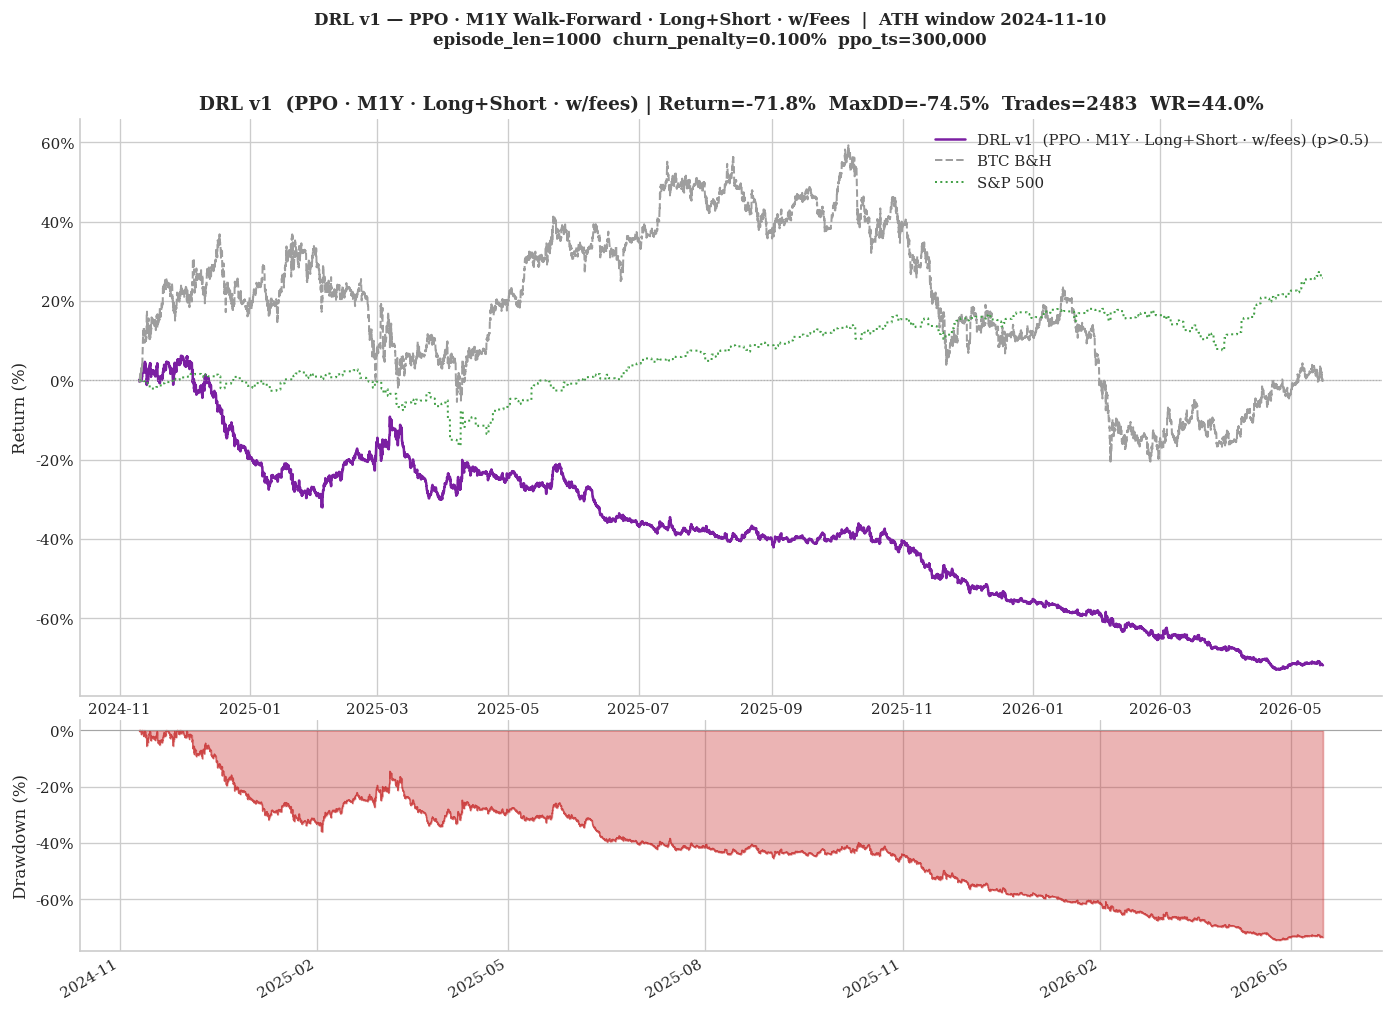

In [8]:
# ── PHASE 4: Equity / drawdown plot ──────────────────────────────────────────
fig = plot_equity_drawdown(
    oos_index_ath, eq_fees_ath, tdf_fees,
    bh_pct=bh_pct, sp500_pct=sp500_pct,
    label='DRL v1  (PPO · M1Y · Long+Short · w/fees)',
    threshold=0.5, color=PURPLE,
)
fig.suptitle(
    f'DRL v1 — PPO · M1Y Walk-Forward · Long+Short · w/Fees  |  ATH window {ATH_START.date()}\n'
    f'episode_len={EPISODE_LEN}  churn_penalty={CHURN_PENALTY:.3%}  ppo_ts={TOTAL_TIMESTEPS:,}',
    fontsize=10, fontweight='bold',
)
save_fig(fig, ARTS_DIR / '01_equity_drawdown.png')
plt.show()

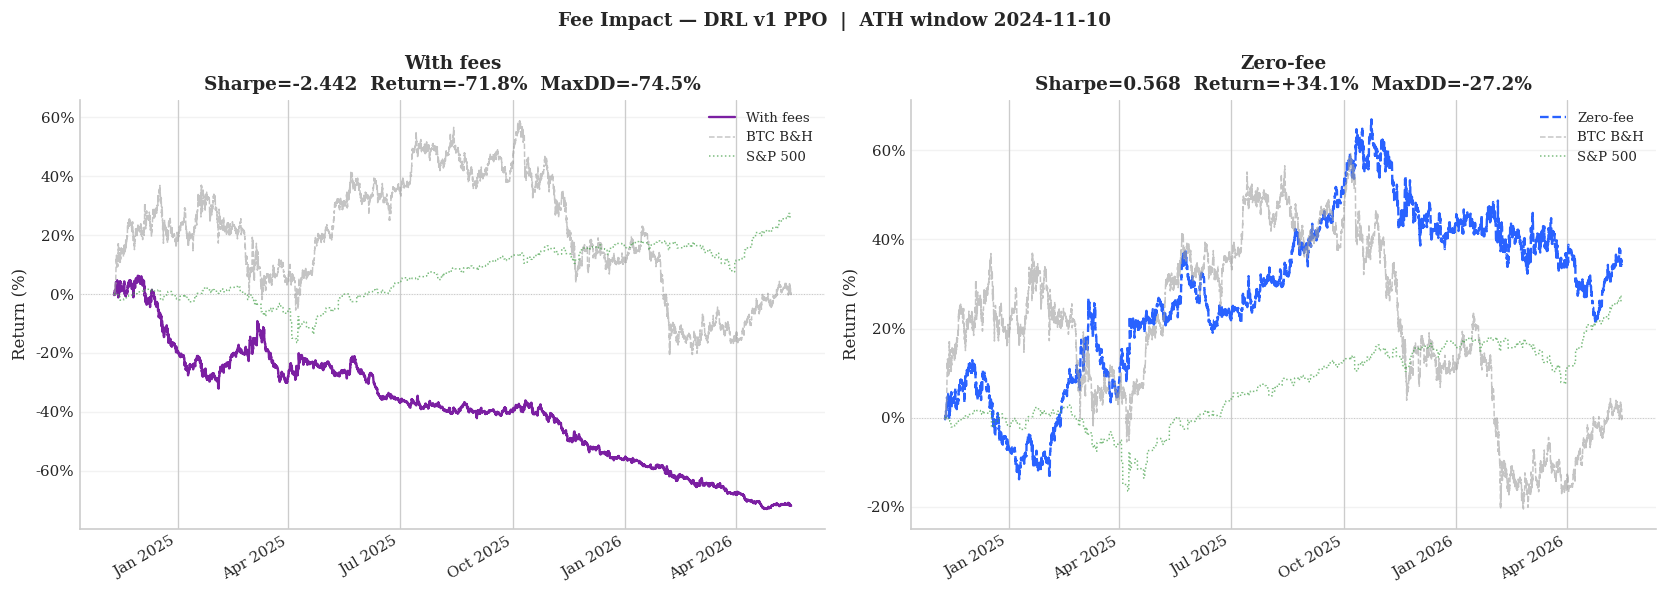

In [9]:
# ── Fee comparison plot ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (lbl, eq, color, ls) in zip(axes, [
    ('With fees', eq_fees_ath, PURPLE, '-'),
    ('Zero-fee',  eq_0fee_ath, BLUE,   '--'),
]):
    ax.plot(oos_index_ath, (eq-1)*100, color=color, lw=1.4, ls=ls, label=lbl)
    ax.plot(oos_index_ath, bh_pct, color=GREY, lw=0.9, ls='--', alpha=0.6, label='BTC B&H')
    if sp500_pct is not None:
        ax.plot(oos_index_ath, sp500_pct.values, color='#43A047', lw=0.9, ls=':', alpha=0.7, label='S&P 500')
    ax.axhline(0, color=GREY, lw=0.6, ls=':', alpha=0.5)
    sh=_sharpe(eq); ret=eq[-1]-1; dd=_maxdd(eq)
    ax.set_title(f'{lbl}\nSharpe={sh:.3f}  Return={ret:+.1%}  MaxDD={dd:.1%}', fontweight='bold')
    ax.set_ylabel('Return (%)'); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v,_: f'{v:.0f}%'))
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle(f'Fee Impact — DRL v1 PPO  |  ATH window {ATH_START.date()}', fontweight='bold', fontsize=11)
fig.tight_layout()
save_fig(fig, ARTS_DIR / '02_fee_comparison.png')
plt.show()

Monthly stats (w/ fees, full OOS):
  Positive months : 7 / 29
  Avg monthly ret : -5.75%
  Median monthly  : -7.57%
  Best month      : +18.41%  (Feb 2025)
  Worst month     : -23.43%  (Dec 2024)


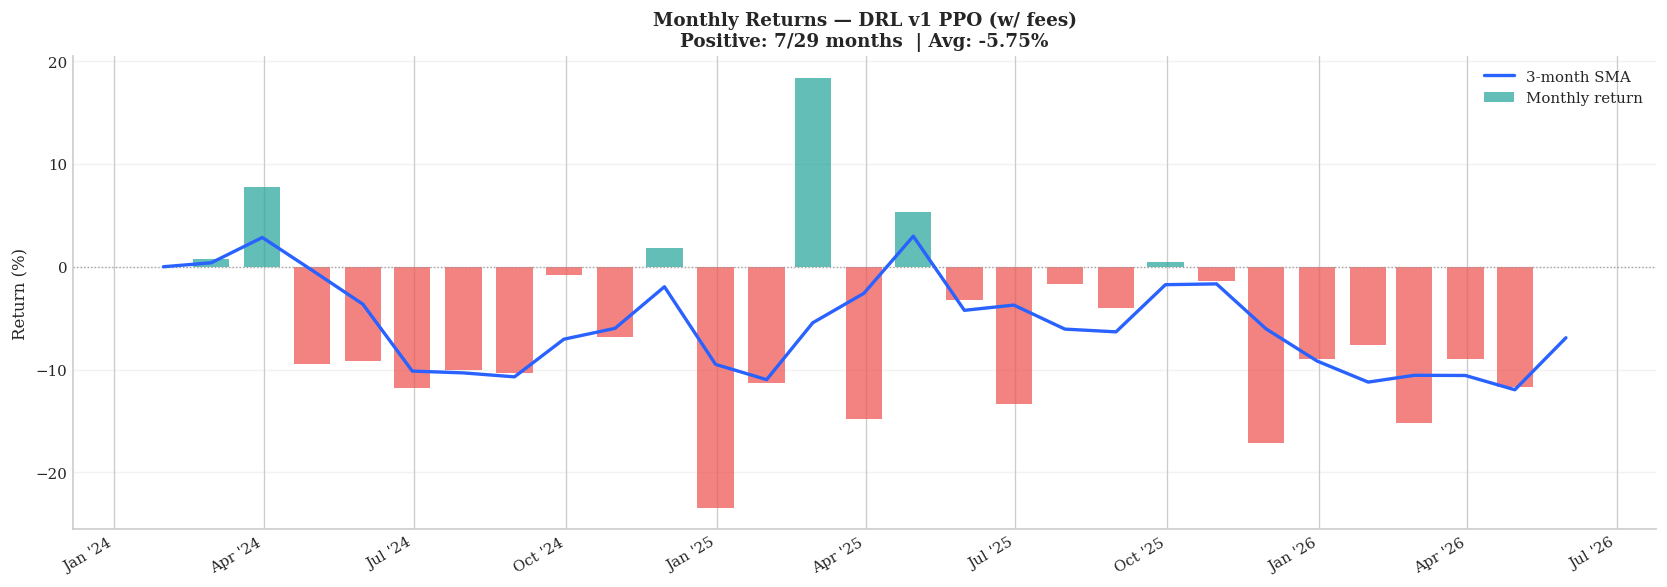

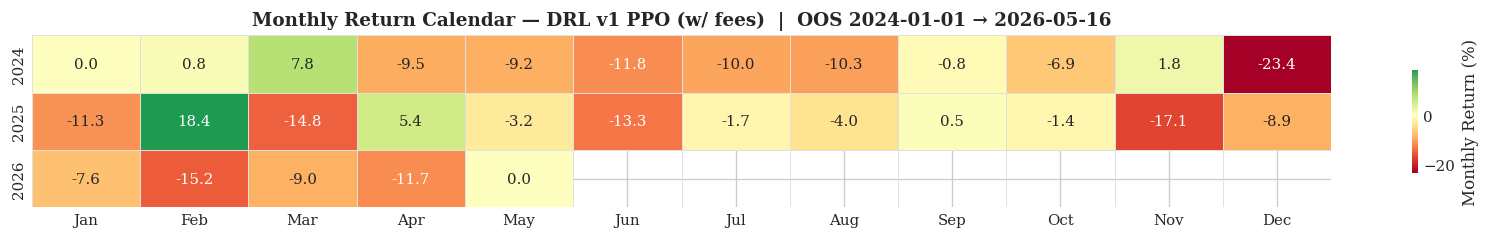

In [10]:
# ── Monthly return analysis ───────────────────────────────────────────────────
eq_full_series = pd.Series(eq_fees, index=oos_df.index)
monthly_eq  = eq_full_series.resample('ME').last()
monthly_ret = monthly_eq.pct_change().fillna(0) * 100
sma3 = monthly_ret.rolling(3, min_periods=1).mean()

print('Monthly stats (w/ fees, full OOS):')
print(f'  Positive months : {(monthly_ret>0).sum()} / {len(monthly_ret)}')
print(f'  Avg monthly ret : {monthly_ret.mean():+.2f}%')
print(f'  Median monthly  : {monthly_ret.median():+.2f}%')
print(f'  Best month      : {monthly_ret.max():+.2f}%  ({monthly_ret.idxmax().strftime("%b %Y")})')
print(f'  Worst month     : {monthly_ret.min():+.2f}%  ({monthly_ret.idxmin().strftime("%b %Y")})')

fig, ax = plt.subplots(figsize=(14, 5))
colors = [GREEN if r >= 0 else RED for r in monthly_ret.values]
ax.bar(monthly_ret.index, monthly_ret.values, color=colors, alpha=0.72, width=22, label='Monthly return')
ax.plot(monthly_ret.index, sma3.values, color=BLUE, lw=2.0, label='3-month SMA', zorder=5)
ax.axhline(0, color=GREY, lw=0.8, ls=':')
ax.set_ylabel('Return (%)')
ax.set_title(f'Monthly Returns — DRL v1 PPO (w/ fees)\n'
             f'Positive: {(monthly_ret>0).sum()}/{len(monthly_ret)} months  '
             f'| Avg: {monthly_ret.mean():+.2f}%', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.25)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '03_monthly_returns.png')
plt.show()

# Calendar heatmap
cal_df = monthly_ret.to_frame('ret').copy()
cal_df['year'] = cal_df.index.year; cal_df['month'] = cal_df.index.month
pivot = cal_df.pivot(index='year', columns='month', values='ret')
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]
fig2, ax2 = plt.subplots(figsize=(14, max(2, len(pivot)*0.7)))
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', center=0, annot=True, fmt='.1f',
            linewidths=0.5, linecolor='#e0e0e0', cbar_kws={'label': 'Monthly Return (%)', 'shrink': 0.6},
            annot_kws={'size': 9})
ax2.set_title(f'Monthly Return Calendar — DRL v1 PPO (w/ fees)  |  OOS {OOS_START.date()} → {oos_df.index[-1].date()}',
              fontweight='bold')
ax2.set_xlabel(''); ax2.set_ylabel('')
fig2.tight_layout()
save_fig(fig2, ARTS_DIR / '04_monthly_heatmap.png')
plt.show()

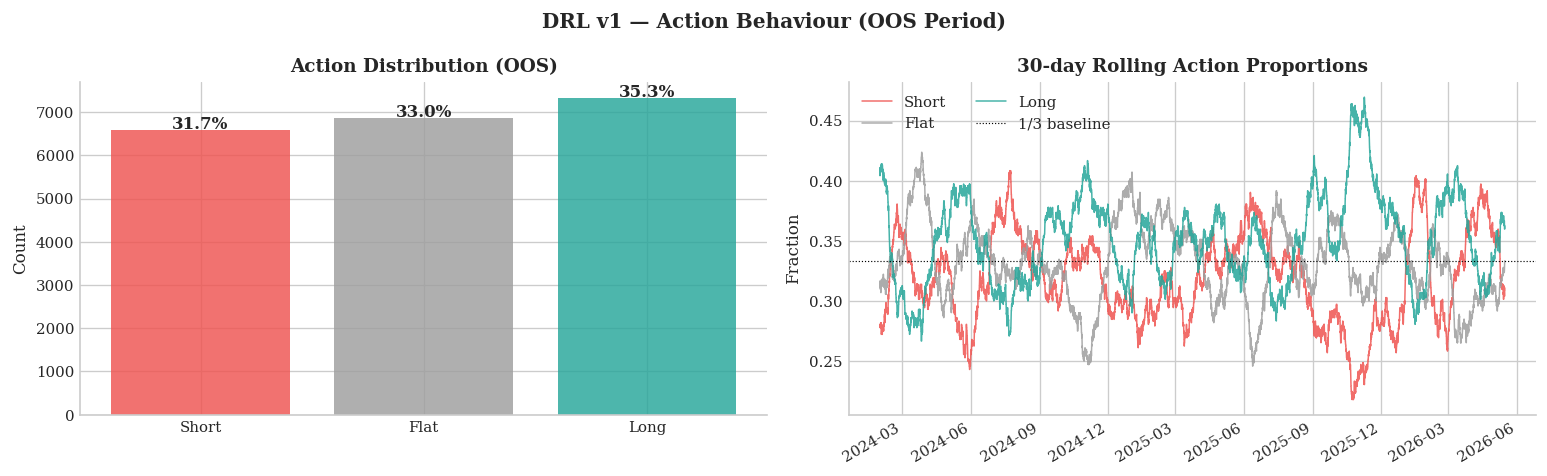

In [11]:
# ── Action distribution over OOS period ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
action_counts = pd.Series(_acts).value_counts().sort_index()
ac_labels = {-1: 'Short', 0: 'Flat', 1: 'Long'}
ac_colors = {-1: RED, 0: GREY, 1: GREEN}
bars = ax.bar([ac_labels[k] for k in action_counts.index],
              action_counts.values,
              color=[ac_colors[k] for k in action_counts.index], alpha=0.82)
for bar, v in zip(bars, action_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
            f'{v/len(_acts)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Action Distribution (OOS)', fontweight='bold')
ax.set_ylabel('Count')

ax = axes[1]
act_series = pd.Series(_acts, index=drl_signals.index)
roll_w = 720
for act_val, col, name in [(-1, RED, 'Short'), (0, GREY, 'Flat'), (1, GREEN, 'Long')]:
    frac = (act_series == act_val).rolling(roll_w).mean()
    ax.plot(frac.index, frac, color=col, lw=0.9, alpha=0.85, label=name)
ax.axhline(1/3, color='black', ls=':', lw=0.7, label='1/3 baseline')
ax.set_title('30-day Rolling Action Proportions', fontweight='bold')
ax.set_ylabel('Fraction'); ax.legend(ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

fig.suptitle('DRL v1 — Action Behaviour (OOS Period)', fontweight='bold')
fig.tight_layout()
save_fig(fig, ARTS_DIR / '05_action_distribution.png')
plt.show()

In [12]:
# ── v0 vs v1 comparison ───────────────────────────────────────────────────────
# Load v0 signals if available for a side-by-side action comparison.
v0_sig_path = REPO_DIR / 'artifacts' / '07_drl_omni_0fee_v0' / 'drl_oos_signals.parquet'
if v0_sig_path.exists():
    v0_sigs = pd.read_parquet(v0_sig_path)['drl_action'].reindex(drl_signals.index).fillna(0).astype(int)
    print('v0 action distribution (OOS):')
    for k, v in v0_sigs.value_counts().sort_index().items():
        name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
        print(f'  {name:5}: {v:5,}  ({v/len(v0_sigs)*100:.1f}%)')
    print('\nv1 action distribution (OOS):')
    for k, v in drl_signals.value_counts().sort_index().items():
        name = {-1: 'Short', 0: 'Flat', 1: 'Long'}.get(k, str(k))
        print(f'  {name:5}: {v:5,}  ({v/len(drl_signals)*100:.1f}%)')
else:
    print('v0 signals not found — run 07_drl_omni_0fee_v0 first for comparison')

v0 action distribution (OOS):
  Short: 7,246  (34.9%)
  Flat : 6,139  (29.5%)
  Long : 7,400  (35.6%)

v1 action distribution (OOS):
  Short: 6,588  (31.7%)
  Flat : 6,866  (33.0%)
  Long : 7,331  (35.3%)


In [13]:
# ── Save results.json ─────────────────────────────────────────────────────────
def _bt_metrics(eq, tdf, label):
    wr  = float((tdf['net']>0).mean()) if len(tdf) else 0.
    n_l = int((tdf['direction']=='long').sum())  if len(tdf) else 0
    n_s = int((tdf['direction']=='short').sum()) if len(tdf) else 0
    return {'label': label, 'n_trades': len(tdf), 'n_long': n_l, 'n_short': n_s,
            'win_rate': round(wr, 4),
            'total_ret': round(float(eq[-1]-1), 4),
            'sharpe': round(_sharpe(eq), 4),
            'maxdd': round(_maxdd(eq), 4),
            'ath_total_ret': round(float(_rebase(eq)[-1]-1), 4),
            'ath_sharpe': round(_sharpe(_rebase(eq)), 4),
            'ath_maxdd': round(_maxdd(_rebase(eq)), 4)}

results = {
    'notebook': '07_drl_omni_0fee_v1',
    'version': 'v1',
    'created': pd.Timestamp.now().isoformat(),
    'algorithm': 'PPO (Stable-Baselines3)',
    'scheme': 'M1Y (1-year sliding)',
    'direction': 'long+short',
    'v1_fixes': {
        'episode_len': EPISODE_LEN,
        'churn_penalty': CHURN_PENALTY,
        'randomised_reset': True,
    },
    'oos_period': f'{OOS_START.date()} → {oos_df.index[-1].date()}',
    'ath_window': f'{ATH_START.date()} → {oos_ath.index[-1].date()}',
    'n_features': len(agent.features),
    'window_size': 24,
    'total_timesteps_per_fold': TOTAL_TIMESTEPS,
    'fees': {'taker': TAKER_FEE, 'funding_h': FUNDING_H},
    'action_dist': {str(k): int(v) for k, v in pd.Series(_acts).value_counts().sort_index().items()},
    'backtest_wfees': _bt_metrics(eq_fees, tdf_fees, 'w_fees'),
    'backtest_0fee':  _bt_metrics(eq_0fee, tdf_0fee, '0_fee'),
    'monthly_returns': {
        'mean_pct': round(float(monthly_ret.mean()), 3),
        'median_pct': round(float(monthly_ret.median()), 3),
        'std_pct': round(float(monthly_ret.std()), 3),
        'positive_months': int((monthly_ret > 0).sum()),
        'total_months': int(len(monthly_ret)),
    }
}

out_path = ARTS_DIR / 'results.json'
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'Saved → {out_path}')
print(json.dumps(results, indent=2)[:1500])

Saved → /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/07_drl_omni_0fee_v1/results.json
{
  "notebook": "07_drl_omni_0fee_v1",
  "version": "v1",
  "created": "2026-06-02T16:46:40.569659",
  "algorithm": "PPO (Stable-Baselines3)",
  "scheme": "M1Y (1-year sliding)",
  "direction": "long+short",
  "v1_fixes": {
    "episode_len": 1000,
    "churn_penalty": 0.001,
    "randomised_reset": true
  },
  "oos_period": "2024-01-01 \u2192 2026-05-16",
  "ath_window": "2024-11-10 \u2192 2026-05-16",
  "n_features": 19,
  "window_size": 24,
  "total_timesteps_per_fold": 300000,
  "fees": {
    "taker": 0.0005,
    "funding_h": 7.7e-06
  },
  "action_dist": {
    "-1": 6588,
    "0": 6866,
    "1": 7331
  },
  "backtest_wfees": {
    "label": "w_fees",
    "n_trades": 2483,
    "n_long": 1323,
    "n_short": 1160,
    "win_rate": 0.4402,
    "total_ret": -0.8603,
    "sharpe": -2.2923,
    "maxdd": -0.8723,
    "ath_total_ret": -0.7184,
    "ath_sharpe": -2.4421,
    